# IBM Telco Customer Churn Prediction - End-to-End Machine Learning Project


## 1. Project Objective

The objective of this project is to develop an end-to-end machine learning pipeline to predict customer churn using the IBM Telco Customer Churn dataset. The project covers the complete machine learning workflow, including data understanding, exploratory data analysis (EDA), data preprocessing, feature engineering, feature selection, model building, model evaluation, cross-validation, hyperparameter tuning, and interpretation of the final model.

The primary goal is to identify the factors influencing customer churn and build a classification model that can accurately predict whether a customer is likely to leave the telecom service. The insights obtained from this analysis can help the company improve customer retention and make data-driven business decisions.


## 2 Import Required Libraries

In [1]:
import numpy as np                         # Numerical operations
import pandas as pd                        # Data manipulation and analysis
import matplotlib .pyplot as plt           # Basic data visualization
import seaborn as sns                      # Statistical data visualization


## 3. Load the dataset

### Purpose
 
Load the IBM Telco Customer Churn dataset into a pandas dataframe to perform data analysis,preprocessing and machine learning.


In [2]:
df = pd.read_csv('../Data/Telco_Customer_Churn.csv')

## 4. Data Understanding

### Purpose

Understand the structure, content and characteristics of the dataset.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Observation: The TotalCharges column contains continuous numerical values, but it is currently stored as the object data type. This suggests that further investigation is required during the preprocessing stage to identify the cause and convert it to the appropriate numerical data type if necessary.

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


##  5. Data Quality Assesment

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [13]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

## 6. Feature Categorization

### 6.1 ID column

In [ ]:

id_column=['customerID']

### 6.2 Numerical columns

In [ ]:

numerical_columns = [column for column in df.columns if df[column].dtype in ['int64','float64']]
print(numerical_columns)

['SeniorCitizen', 'tenure', 'MonthlyCharges']


### 6.3 Discrete numerical columns

In [ ]:

discrete_columns = [column for column in numerical_columns if df[column].nunique()<=10]
print(discrete_columns)


['SeniorCitizen']


 ### 6.4 Continuous numerical columns

In [ ]:


continuous_columns = [column for column in numerical_columns if df[column].nunique()>10]
print(continuous_columns)

['tenure', 'MonthlyCharges']


### 6.5 Categorical columns

In [18]:
categorical_columns = [column for column in df.columns if df[column].dtypes=='object'] 

categorical_columns.remove('customerID')
categorical_columns.remove('TotalCharges')
print(categorical_columns)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


### 6.6 Explore Feature Labels

In [ ]:

for column in categorical_columns:
    print(f"\n {column}")
    print(df[column].unique())


 gender
['Female' 'Male']

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']

 Contract
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling
['Yes' 'No']

 PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 Churn
['No' 'Yes']


## 7. Data Preprocessing

### 7.1 Investigate **TotalCharges**

In [20]:
df['TotalCharges'].dtype


dtype('O')

In [21]:
df['TotalCharges'].head(10)


0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [22]:
(df['TotalCharges']==' ').sum()


np.int64(11)

In [23]:
df[df['TotalCharges']==' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [24]:
df.loc[df['TotalCharges']==' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [25]:
df.loc[df['TotalCharges']==' ',['customerID','tenure','MonthlyCharges','TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [26]:
blank_index = df[df['TotalCharges']==' '].index

print(blank_index)

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')


### 7.2 Convert Total Charges to Numeric

In [27]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

### 7.3 Verify the conversion

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [29]:
df['TotalCharges'].isnull().sum()

np.int64(11)

### 7.4 Handle Missing Values in **TotalCharges**

Observation: After converting TotalCharges to a numeric data type, 11 blank entries were converted to NaN. Investigation showed that all these customers had tenure = 0, indicating they were new customers who had not yet completed their first billing cycle. Therefore, TotalCharges was imputed with 0 based on business logic rather than using a statistical imputation method.

In [30]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

### 7.5 Verify the Preprocessing

In [31]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 7.6 Drop Unnecessary Features

In [32]:
df.drop('customerID',axis=1,inplace =True)

In [33]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### 7.7 Update Feature Categories

In [34]:

numerical_columns = [column for column in df.columns if df[column].dtype in ['int64','float64']]
discrete_columns = [column for column in numerical_columns if df[column].nunique()<=10]
continuous_columns = [column for column in numerical_columns if df[column].nunique()>10]



## 8. Exploratory Data Analysis (EDA)

### 8.1 Target Variable Analysis

### Purpose
To understand the distribution of the target variable (Churn) by examining the frequency, percentage distribution, and class balance. This helps identify class imbalance and provides an overview of the target variable before building a classification model.




### 8.1.1 Count of  each class

In [35]:
df['Churn'].value_counts() 

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### 8.1.2 Percentage distribution

In [36]:
df['Churn'].value_counts(normalize=True)*100 

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### 8.1.3 Count Plot

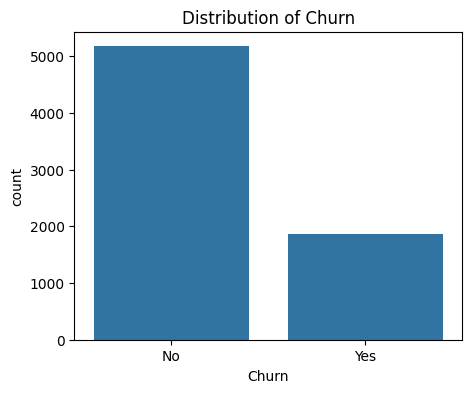

In [37]:
plt.figure(figsize=(5,4)) 
sns.countplot(data=df, x='Churn') 
plt.title('Distribution of Churn')
plt.show()

### Observation

The target variable contains two classes: Yes (customer churned) and No (customer did not churn). The frequency table, percentage distribution, and count plot show that the No class has more observations than the Yes class. This indicates that the dataset has a moderate class imbalance, with a larger proportion of customers remaining with the company than leaving it.

### Insight

Since the target variable is moderately imbalanced, relying only on accuracy may not provide a complete evaluation of the classification model. Therefore, additional metrics such as Precision, Recall, F1-score, and ROC-AUC should also be considered during model evaluation. If the imbalance negatively affects model performance, techniques such as oversampling, undersampling, or SMOTE can be explored.

### 8.2 Univariate Analysis

### 8.2.1 Histogram (Continous Numercal Features)

### Purpose

To visualize the distribution of all continous numerical features using histograms . This helps identify the shape of the distribution, detect skewness, assess normality, and understand the spread of each feature.

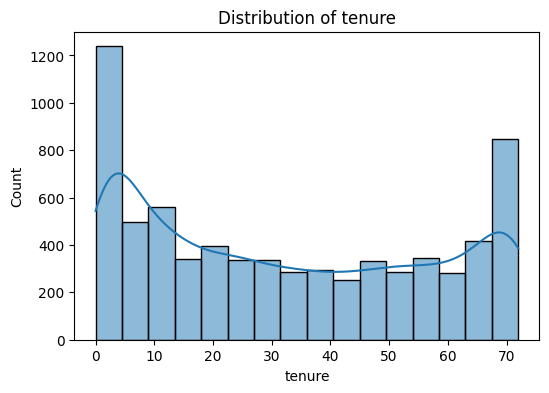

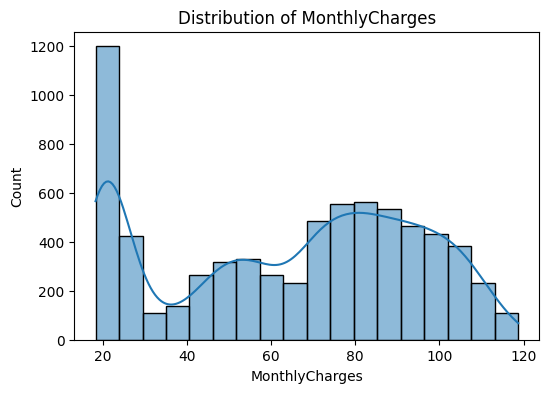

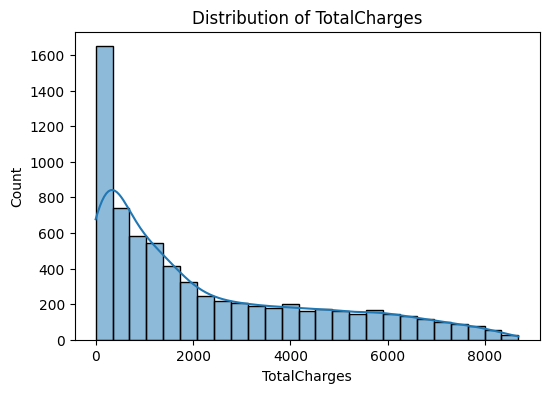

In [38]:
for column in continuous_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column],kde =True)
    plt.title(f"Distribution of {column}")
    plt.show()

### Observation

The **tenure** feature ranges from 0 to 72 months. The distribution is not normally distributed and is not symmetric. It shows two noticeable concentrations of customers: one at the beginning (around 0–5 months) and another at the end (around 70–72 months). Comparatively fewer customers fall in the middle tenure range. Overall, the data is concentrated at the beginning and the end of the tenure period rather than being evenly distributed across all months.


The **MonthlyCharges** feature ranges approximately from 18 to 120. The distribution is not normally distributed and is not symmetric. A large number of customers have monthly charges around 20–30. Another concentration of customers is observed between 70 and 100. The data is spread across the entire range, with more customers concentrated in the lower and higher monthly charge ranges than in the middle.
Insight

The **TotalCharges** feature ranges approximately from 0 to 9000. The distribution is not normally distributed and is positively (right) skewed, with a long tail extending toward higher values. Most customers have relatively low total charges, while the frequency gradually decreases as the total charges increase. This indicates that only a smaller proportion of customers have accumulated very high total charges.






### Insight

The histogram of **tenure** indicates that the dataset contains both newly joined customers and long-term customers. This suggests that customer tenure may be an important factor influencing customer churn, which will be investigated further during the bivariate analysis.

The histogram of **MonthlyCharges**indicates that customers subscribe to different service plans with varying monthly charges. Since the monthly charges vary considerably across customers, this feature may play an important role in predicting customer churn. Its relationship with the target variable (Churn) will be explored during the bivariate analysis.

The right-skewed distribution of **TotalCharges** suggests that many customers have relatively low accumulated charges, whereas only a few customers have very high total charges. This may be because many customers are new or have lower monthly charges, while long-term customers accumulate higher total charges over time. The relationship between TotalCharges and customer churn will be examined further during the bivariate analysis.



### 8.2.2 Boxplot (Continous Numerical Features)

### Purpose 
To summarize the distribution of continuous numerical features using the five-number summary (minimum, Q1, median, Q3, and maximum). Box plots help identify the interquartile range (IQR), detect outliers, understand the spread of the middle 50% of the data, and assess the symmetry of the distribution.


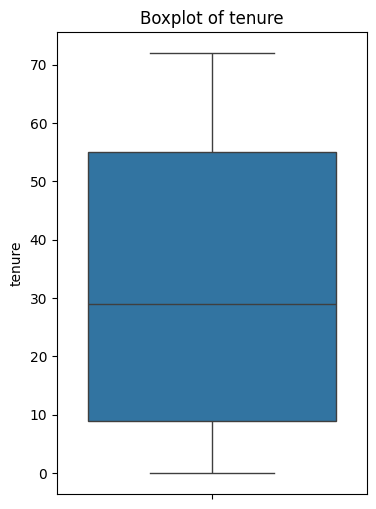

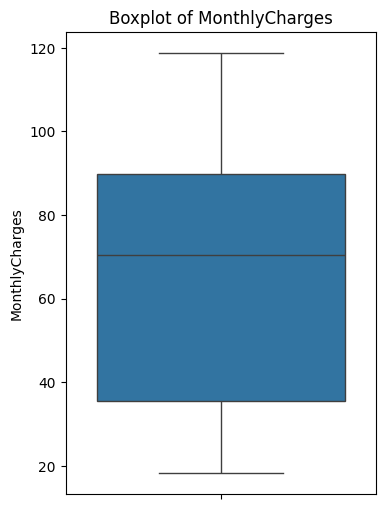

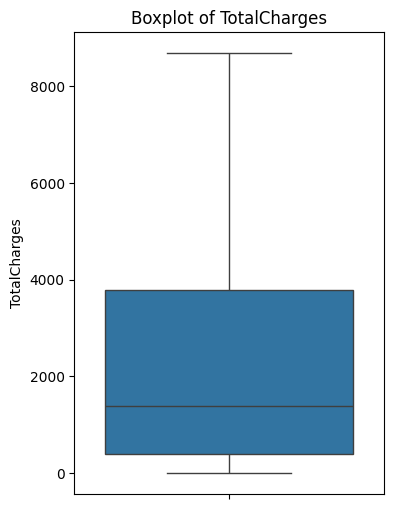

In [39]:
for column in continuous_columns:
    plt.figure(figsize=(4,6))
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

### Observation

The tenure feature ranges from approximately 0 to 72 months. The first quartile (Q1) is around 10 months, which means 25% of the customers have a tenure of up to approximately 10 months. The median (Q2) is around 30 months, indicating that 50% of the customers have a tenure of up to approximately 30 months, while the remaining 50% have a tenure greater than 30 months. The third quartile (Q3) is approximately 55 months, meaning 75% of the customers have a tenure of up to approximately 55 months. Therefore, the middle 50% of the customers have a tenure between approximately 10 and 55 months. The median is closer to the lower quartile (Q1) than to the upper quartile (Q3), indicating that the middle 50% of the data is not evenly distributed within the IQR. No significant outliers are observed in the tenure feature.

The MonthlyCharges feature ranges from approximately 18 to 118. The first quartile (Q1) is around 35, indicating that 25% of the customers pay a monthly charge of up to approximately $35. The median (Q2) is around 70, which means 50% of the customers pay a monthly charge of up to approximately $70, while the remaining 50% pay more than $70. The third quartile (Q3) is around 90, indicating that 75% of the customers pay a monthly charge of up to approximately $90. Therefore, the middle 50% of the customers have monthly charges between approximately $35 and $90. The median is slightly closer to Q3 than to Q1, suggesting that the distribution of the middle 50% is not perfectly symmetric. No significant outliers are observed in this feature.

The TotalCharges feature ranges from approximately 0 to 9000. The first quartile (Q1) is approximately $500, indicating that 25% of the customers have accumulated total charges of up to approximately $500. The median (Q2) is around $1,500, which means 50% of the customers have accumulated total charges of up to approximately $1,500, while the remaining 50% have accumulated more than this amount. The third quartile (Q3) is approximately $4,000, indicating that 75% of the customers have accumulated total charges of up to approximately $4,000. Therefore, the middle 50% of the customers have accumulated total charges between approximately $500 and $4,000. The median is closer to the lower quartile (Q1) than to the upper quartile (Q3), indicating that the distribution of the middle 50% of the data is not perfectly symmetric. No significant outliers are observed in the TotalCharges feature.


### Insight

The absence of significant outliers indicates that outlier treatment is not required for the tenure feature. The relatively wide interquartile range suggests that customers have a broad range of service durations, from recently joined customers to long-term customers. Since customer tenure varies considerably across the dataset, it is likely to be an important feature for predicting customer churn. This relationship will be explored further during the bivariate analysis.

Since no significant outliers are present, outlier treatment is not required for the MonthlyCharges feature. The wide interquartile range indicates that customers subscribe to service plans with varying monthly charges. Therefore, MonthlyCharges is likely to be an important feature for understanding customer behavior and predicting churn.

The absence of significant outliers indicates that outlier treatment is not required for the TotalCharges feature. The wide interquartile range shows that customers have accumulated a broad range of total charges during their time with the company. This variation is expected because TotalCharges is influenced by both MonthlyCharges and tenure. Customers who stay with the company for a longer period or who pay higher monthly charges generally accumulate higher total charges. Therefore, TotalCharges is likely to be an important feature for predicting customer churn, and its relationship with the target variable will be explored further during the bivariate analysis.


### 8.2.3 Countplot (Discrete Numerical Feature)

### Purpose

To visualize the distribution of discrete numerical features by examining the frequency of each value. This helps identify dominant and less frequent values and understand the characteristics of the feature before further analysis.

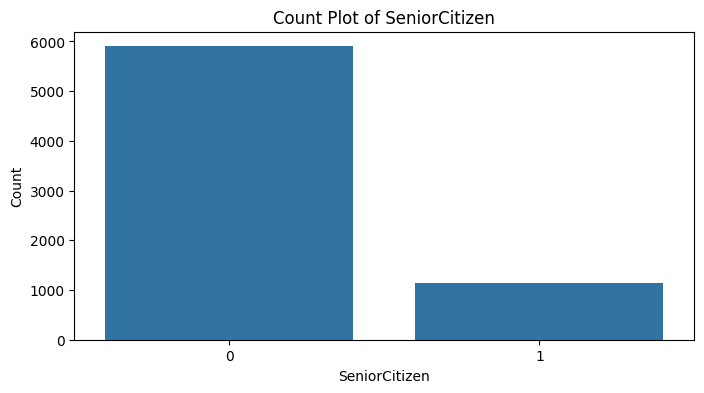

In [40]:
plt.figure(figsize=(8,4))
sns.countplot(x='SeniorCitizen',data=df)
plt.title('Count Plot of SeniorCitizen')
plt.xlabel('SeniorCitizen')
plt.ylabel('Count')
plt.show()

### Observation

The SeniorCitizen feature contains two discrete values: 0 (not a senior citizen) and 1 (senior citizen). The count plot shows that customers with the value 0 are much more frequent than customers with the value 1. This indicates that the majority of customers in the dataset are not senior citizens.

### Insight

The SeniorCitizen feature shows a clear difference in the frequency of its two values. Since it is a binary predictor variable, no additional preprocessing is required. However, it may influence customer churn, and its relationship with the target variable will be examined during the bivariate analysis.


### 8.2.4 Countplot (Categorical Features)

### Purpose

To visualize the distribution of categorical predictor features by examining the frequency of each category. This helps identify dominant and less frequent categories, verify valid category labels, and understand customer characteristics before bivariate analysis and feature encoding.


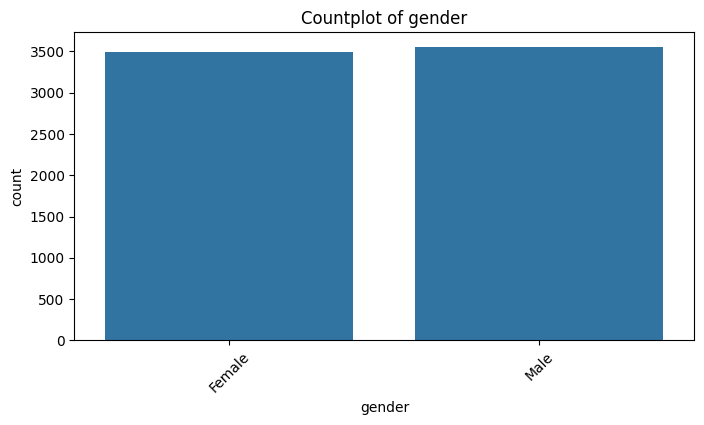

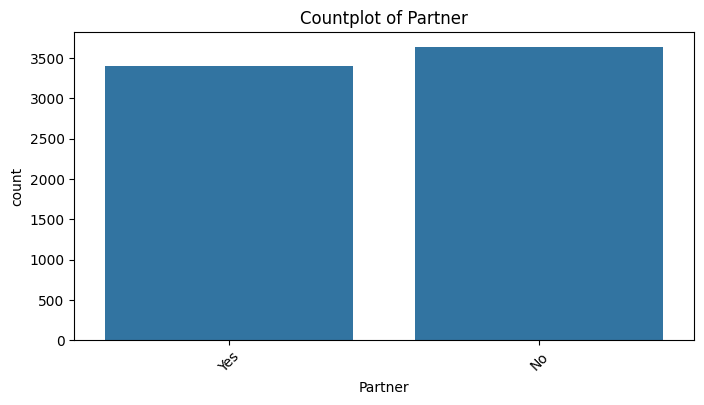

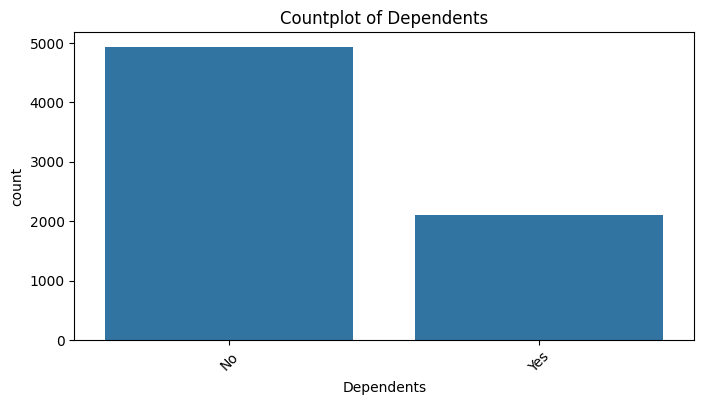

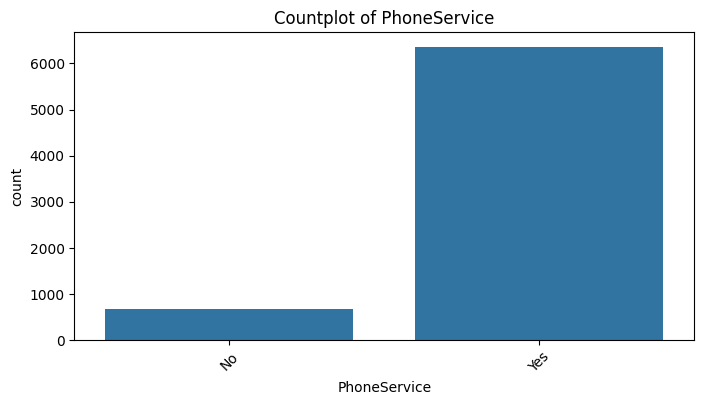

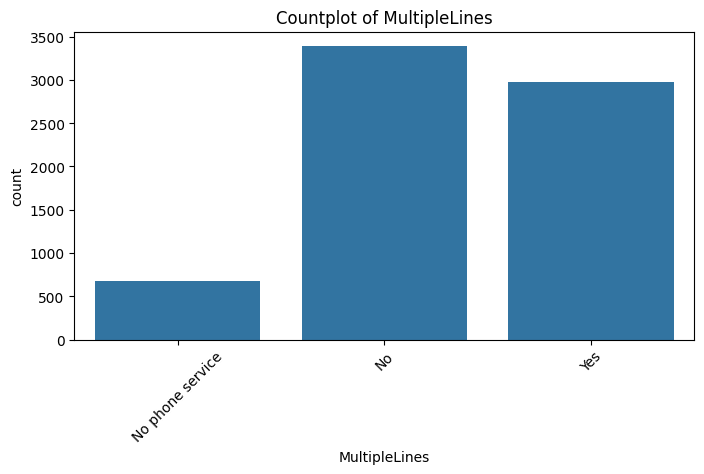

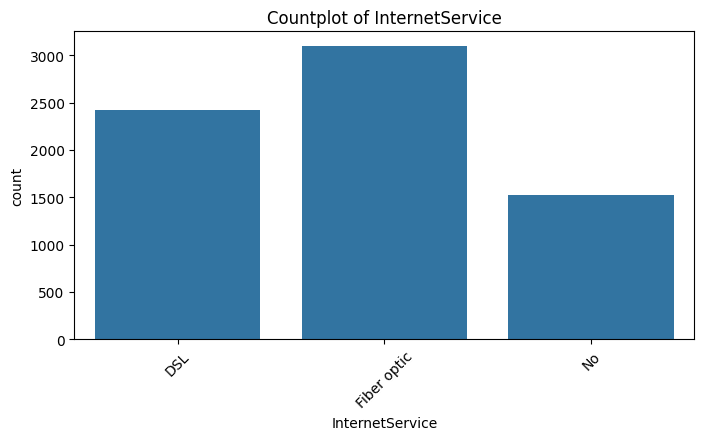

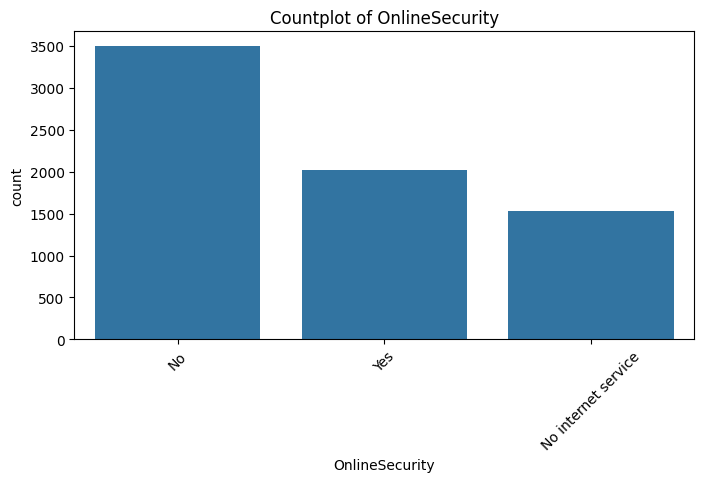

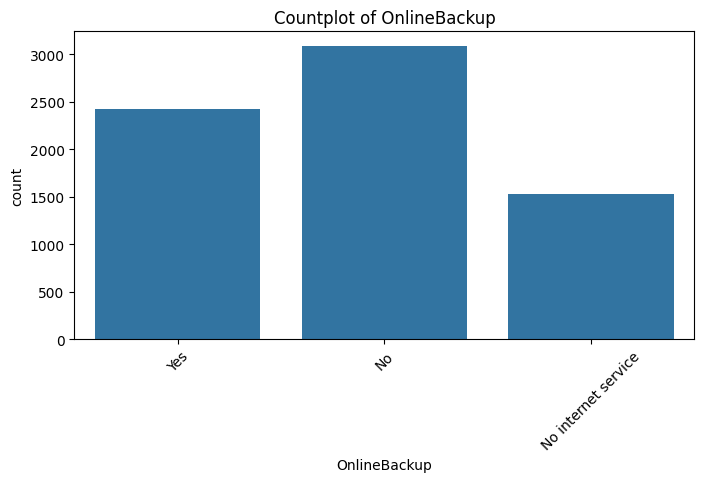

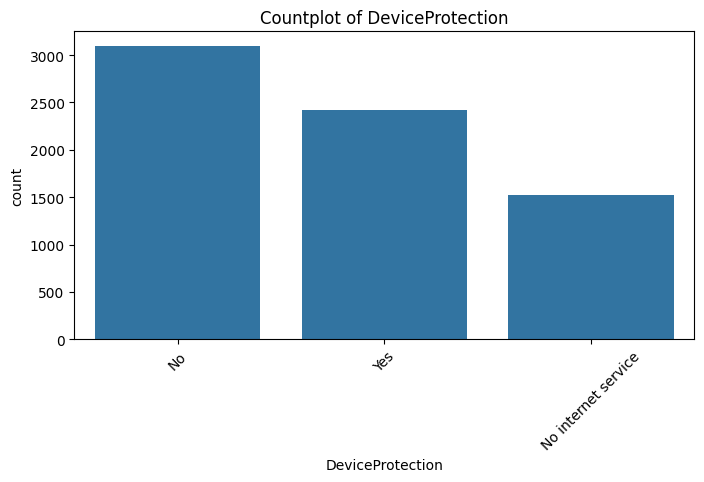

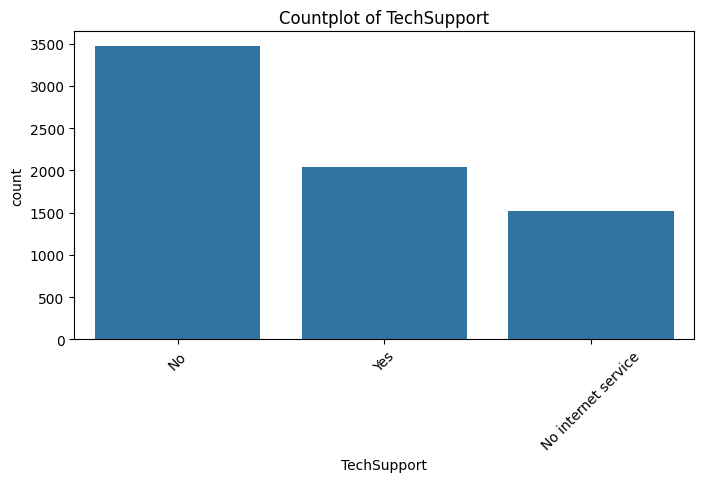

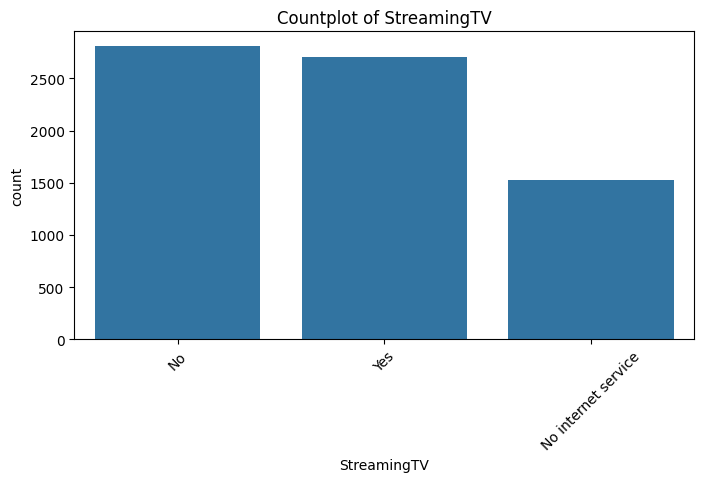

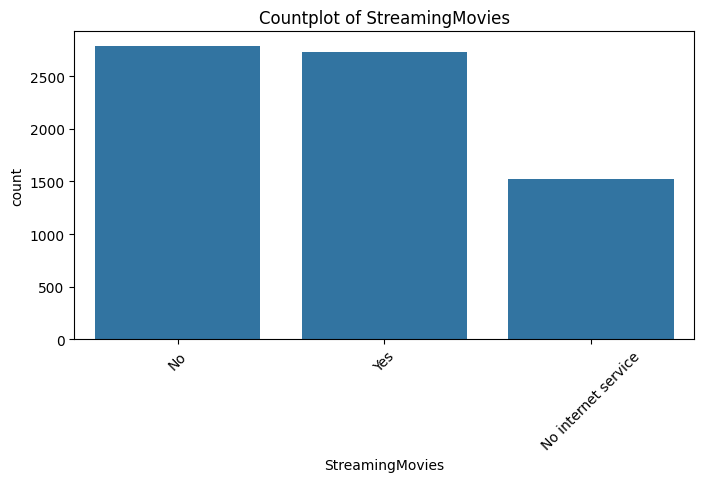

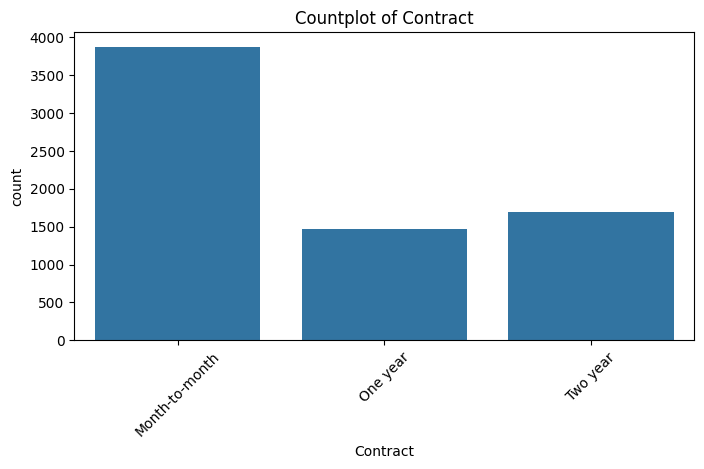

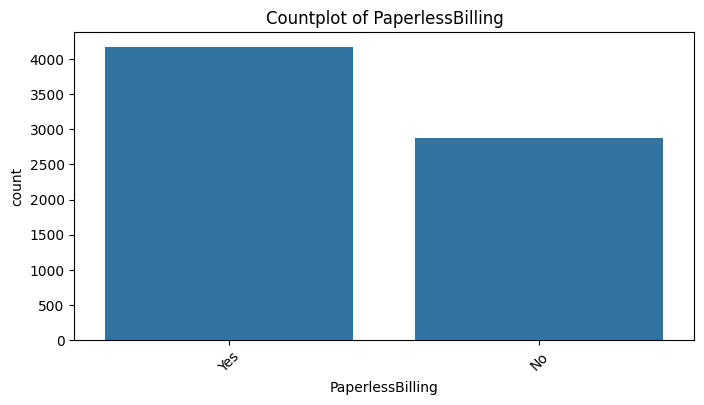

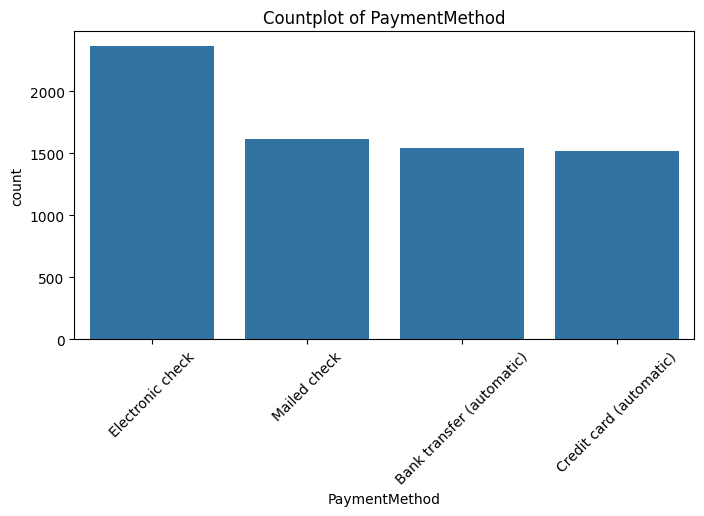

In [52]:
for column in categorical_columns:
    if column!='Churn':
        plt.figure(figsize=(8,4))
        sns.countplot(x=column,data=df)
        plt.xticks(rotation=45)
        plt.title(f"Countplot of {column}")
        plt.show()

### Observation 

The count plots show that most categorical features contain two or three categories. Several binary features, such as Partner, Dependents, PhoneService, and PaperlessBilling, are dominated by one category, while other features such as InternetService, Contract, and PaymentMethod contain multiple categories with different frequencies. Overall, the categorical features have meaningful category distributions and do not contain unusual or unexpected labels. The target variable Churn was analyzed separately in the Target Variable Analysis section.

### Insight
The count plots provide an overview of the categorical feature distributions and help identify dominant categories. These distributions are useful for understanding customer characteristics and selecting appropriate encoding techniques during preprocessing. The relationship between these categorical features and customer churn will be examined further during the bivariate analysis.



## 8.3 Bivariate Analysis

### 8.3.1 Continuous Features vs Churn

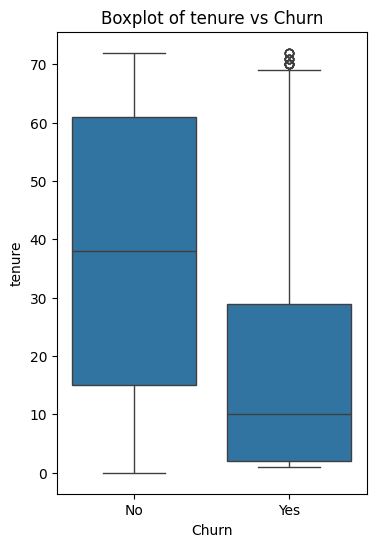

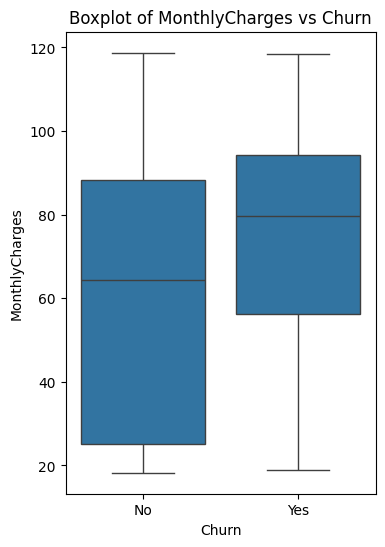

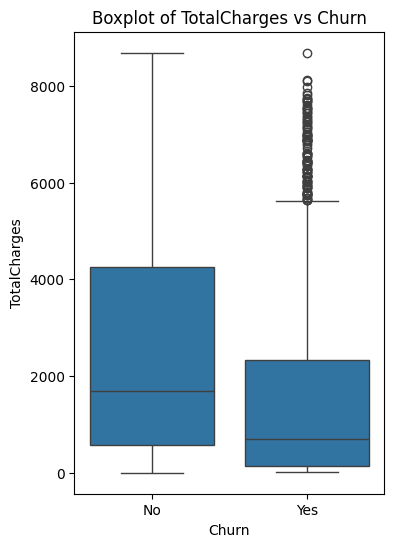

In [42]:
for column in continuous_columns:
    plt.figure(figsize=(4,6))
    sns.boxplot(x='Churn',y=df[column],data=df)
    plt.title(f"Boxplot of {column} vs Churn")
    plt.show()

### 8.3.2 Discrete Feature vs Churn

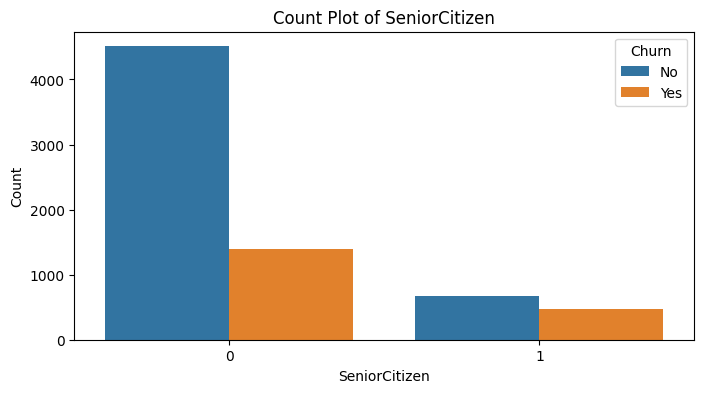

In [43]:
plt.figure(figsize=(8,4))
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)
plt.title('Count Plot of SeniorCitizen')
plt.xlabel('SeniorCitizen')
plt.ylabel('Count')
plt.show()

### 8.3.3 Categorical Features vs Churn

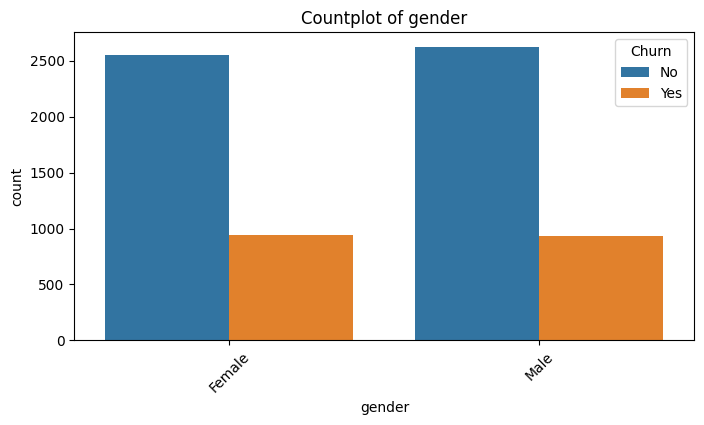

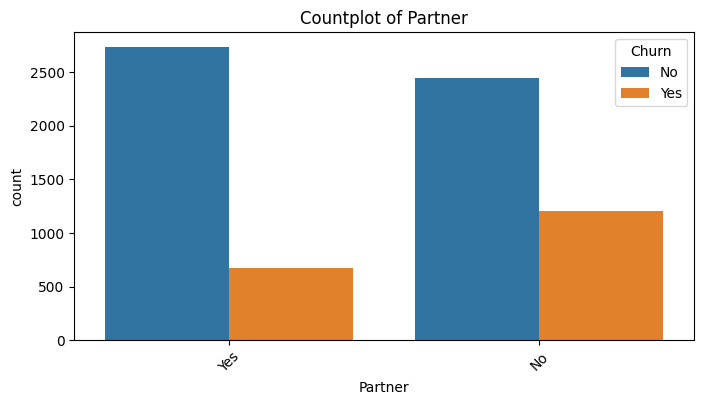

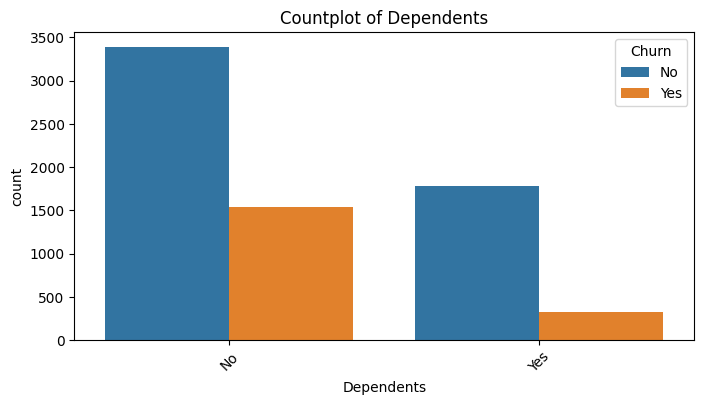

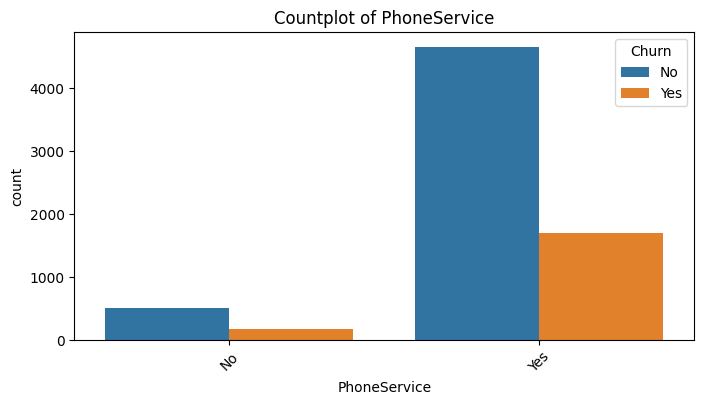

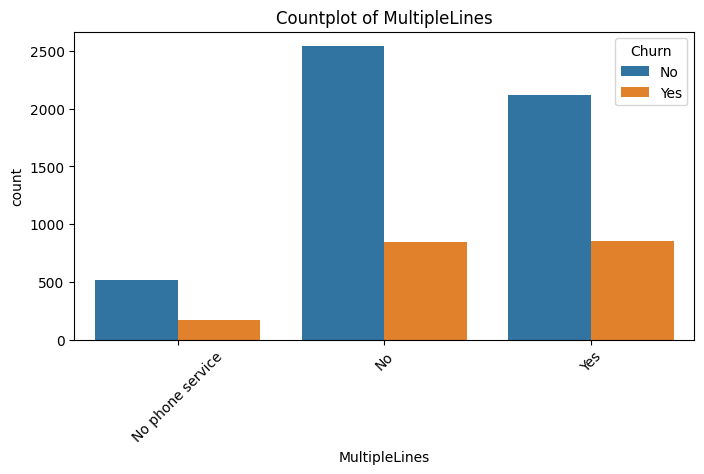

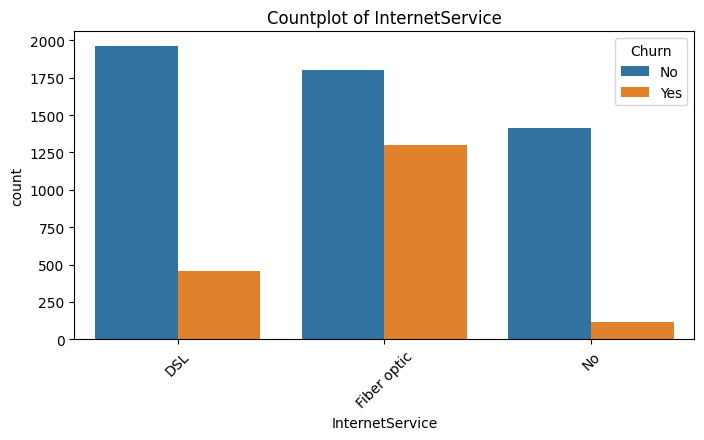

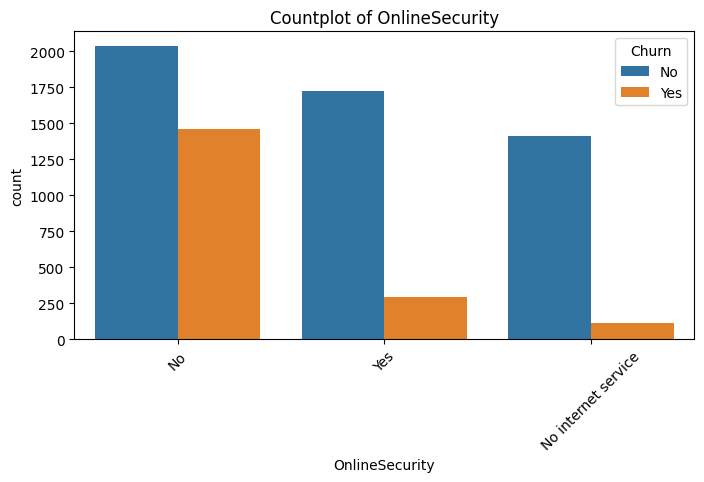

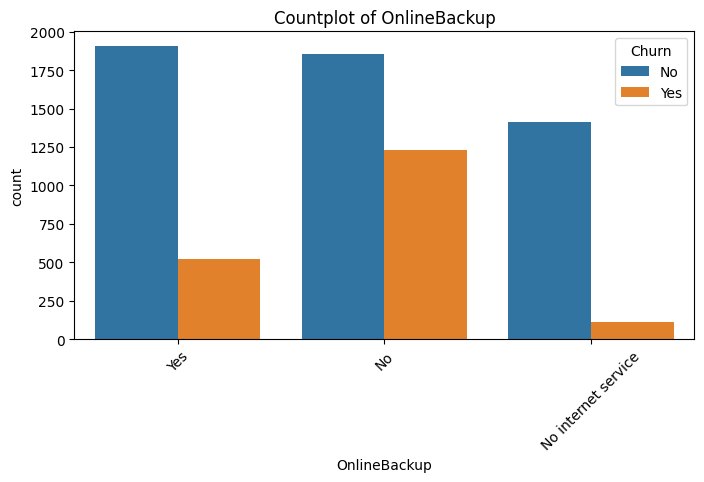

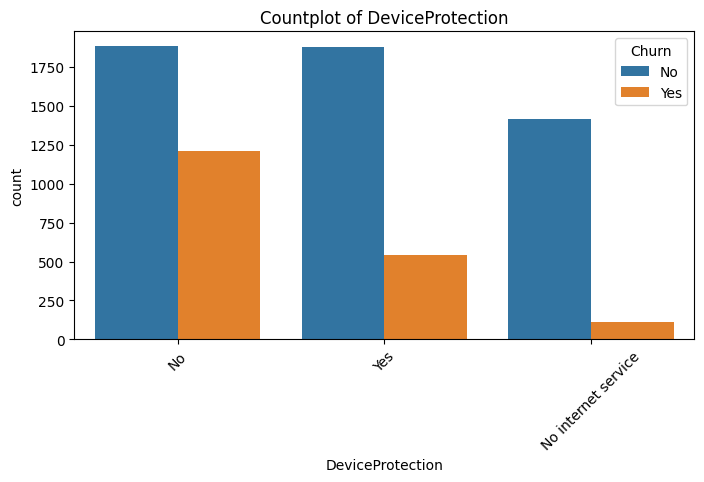

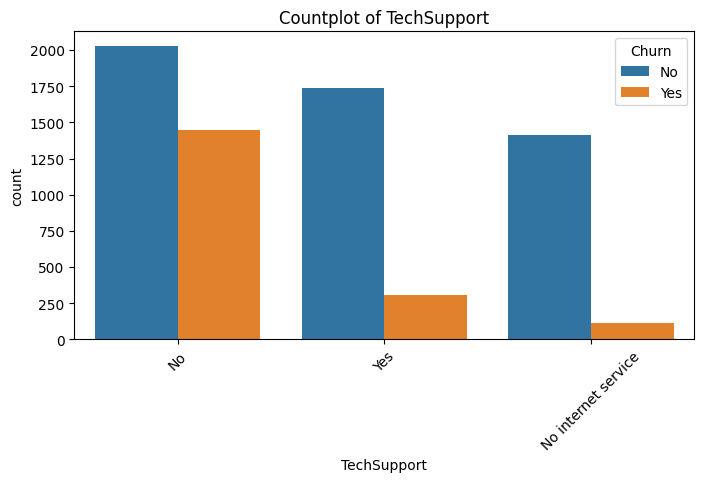

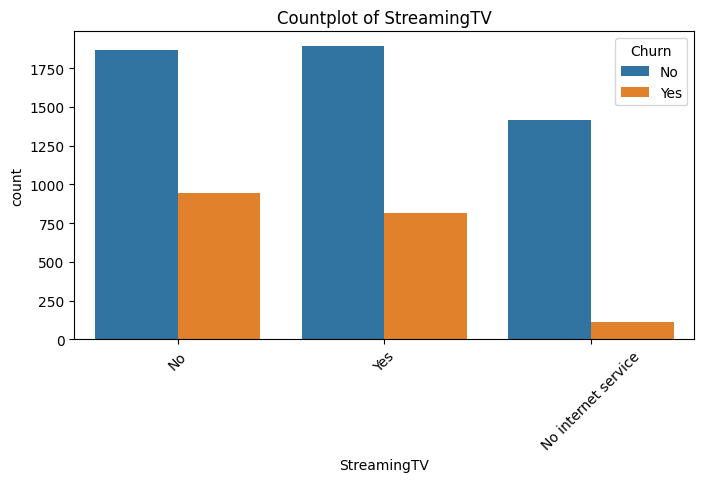

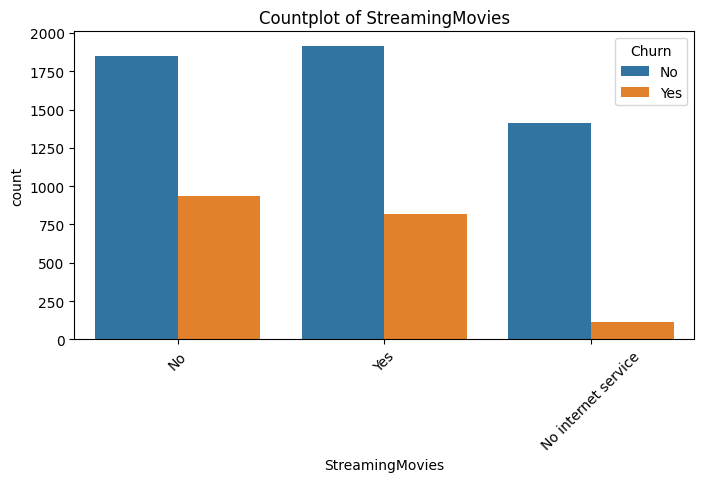

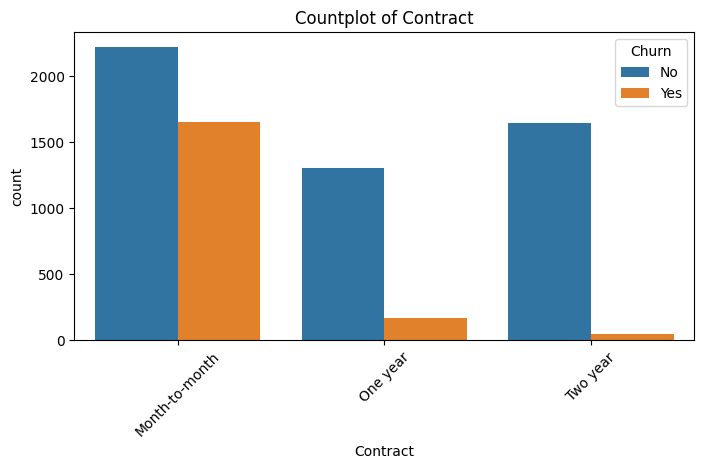

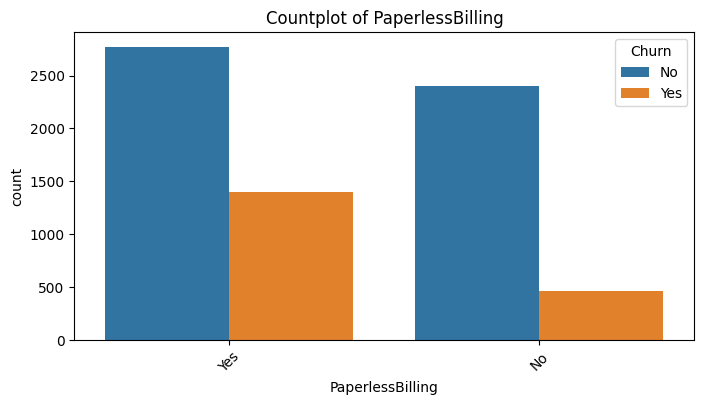

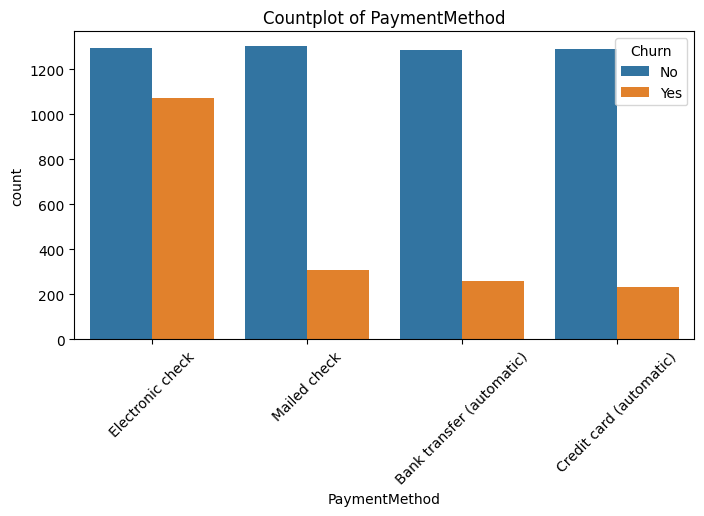

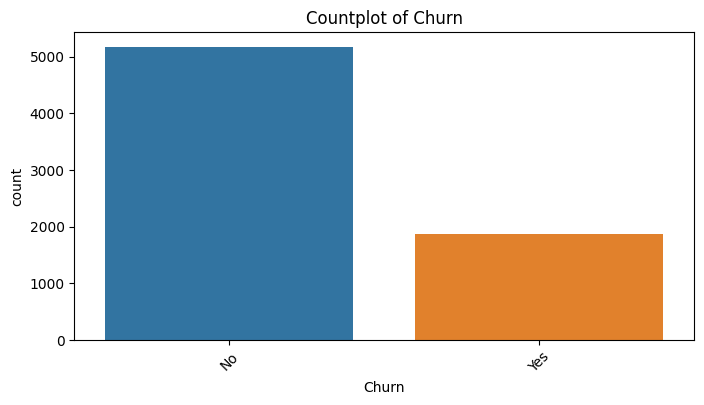

In [44]:
for column in categorical_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=column,hue='Churn',data=df)
    plt.xticks(rotation=45)
    plt.title(f"Countplot of {column}")
    plt.show()

## 8.4 Multivariate Analysis


### 8.4.1 Correlation Heatmap

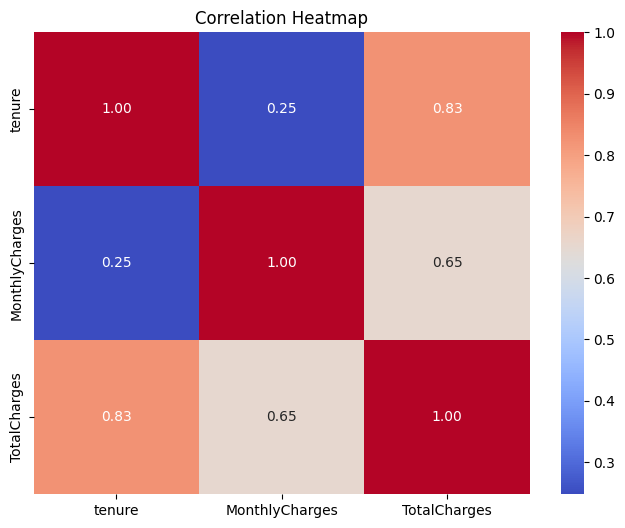

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[continuous_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()


## 8.4.2 Pair Plot

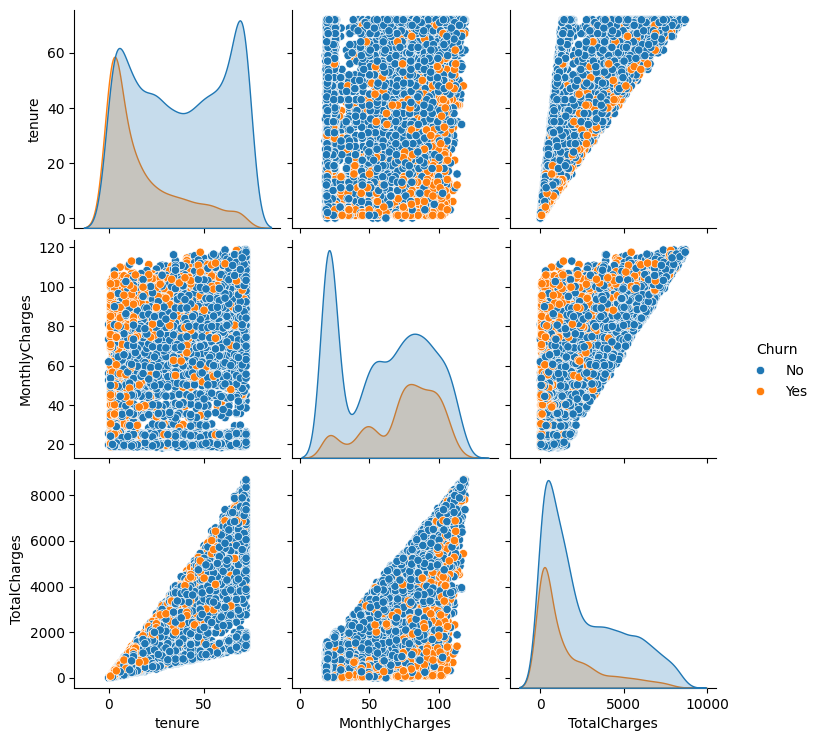

In [46]:
sns.pairplot(
    df,
    vars=continuous_columns,
    hue='Churn'
)
plt.show()


## 8.4.3 Scatter Plot

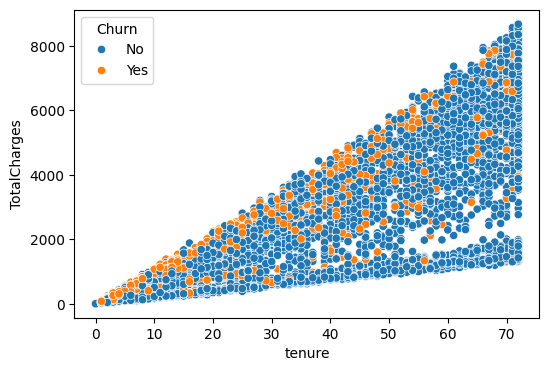

In [47]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x='tenure',
    y='TotalCharges',
    hue='Churn'
)
plt.show()


## 8.4.4 Cross Tab

In [48]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [49]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858
